<a href="https://colab.research.google.com/github/catarina1532/pml/blob/main/T8_torch_NN_pipeline_and_questions_for_assign_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [25]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [26]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((8, 8)),         # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Finally, flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
**The train and test dataloaders contain tensors (arrays of numbers). One tensor with image data and one tensor with labels, both being pytorch tensors (`torch.Tensor`). Each iteration returns: (images, labels).**

- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape? **Shape represents how many rows and columns. Images were resized to 8x8, converted to tensors and were flatten. Images have 64 pixels. A vector 64x1 is going to be the input of the neural network, matching the size created. Labels in this case are one number for each row. The shape is: [batch_size, 64]. For the current notebook: torch.Size([64, 64]). Interpretation: first dimension (64) = number of images in the batch, second dimension (64) = flattened image pixels. Since images were resized to 8x8, each image has: 8 × 8 = 64 pixels. The transform: transforms.Lambda(lambda x: x.view(-1)) flattens each image into a 1D vector.**

- Why dataloaders for train and test differ with respect to the option `shuffle`? **Data for training shuffles, for testing it doesn't. The idea of shuffling is for each epoch to use a different batch of examples, allowing to explore more the domain of the weights, giving more range to explore solutions. The training dataloader uses `shuffle=True` because shuffling improves training by preventing the model from learning the order of examples, reducing bias during gradient updates and improving generalization. The test dataloader uses `shuffle=False` because evaluation should be deterministic, the order does not affect testing and reproducibility is important for validation/testing. It doesn't make sense to shuffle because it wants to predict for all of the examples.**

#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

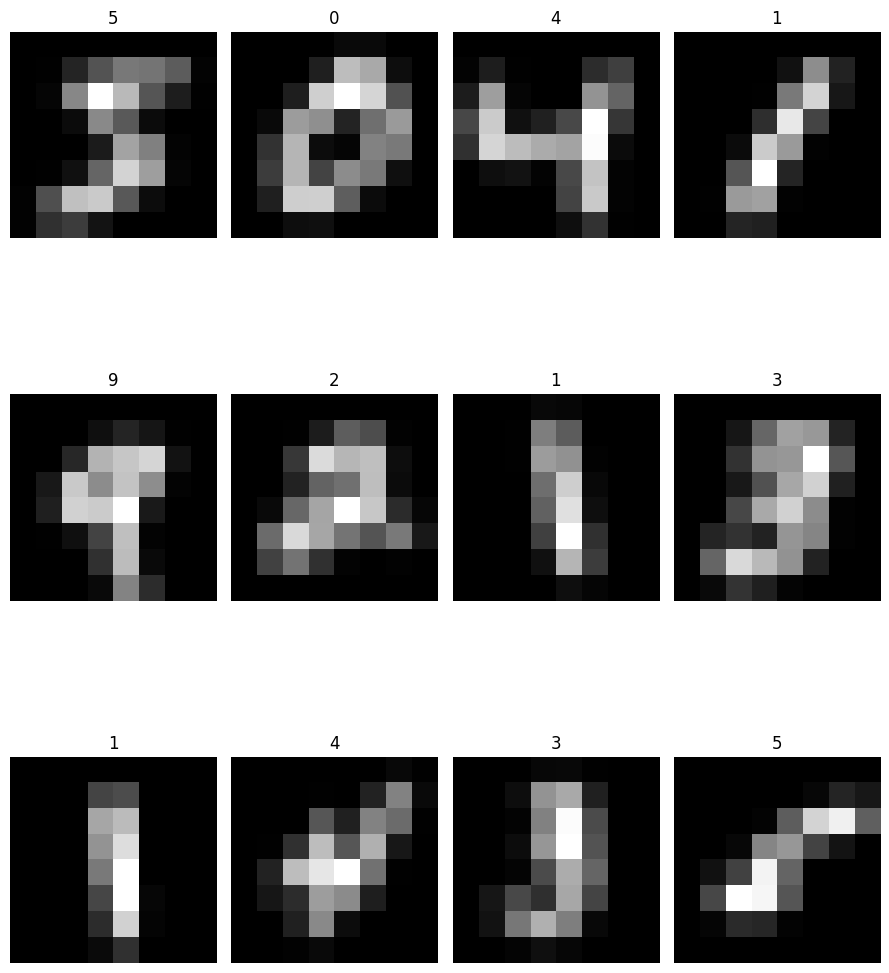

In [27]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [28]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook. **To use the original 28×28 MNIST images, two changes are necessary. First, in the data preparation code block, the resizing transform to 8×8 in the line `transforms.Resize((8, 8))` should be removed, so the original image dimensions are preserved. Second, in the model development code block, the model input size must be changed from  `input_size = 8x8` to `input_size = 28x28` because flattened 28×28 images contain 784 pixels, which matches the model input size 784.**

- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128? **A second hidden layer must be added to the model, making it more flexible and a deep learning type of model. The class would need another nn.Linear and another activation function. The same hidden layer size 128 would be maintained.**

- What is a `ReLU` activation function called by `nn.ReLU`? **`ReLU` stands for Rectified Linear Unit and is defined as f(x) = max(0, x). It keeps positive values and replaces negative values with zero.**

- Why are non linear activation functions like `ReLU` necessary for deep learning? **Without non linear activation functions in between the fully connected neural network, the linear layers would collapse into a single model. Non linear activation functions enable representation of non linear relationships and make deep learning possible by allowing the model to learn complex patterns, which is essential for tasks such as image classification.**

#####**Edit: two hidden layers**

*prompt*: generate a pytorch neural network with two hidden layers of size 128 for MNIST classification

In [29]:
'''
# Model Development: the model is a multilayer perceptron with two hidden layers
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

# Since we are using 28x28 MNIST and flatenning the input, the input size is 28 * 28 = 784
input_size = 28 * 28
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)
'''

'\n# Model Development: the model is a multilayer perceptron with two hidden layers\nclass SimpleNN(nn.Module):\n    def __init__(self, input_size, hidden_size, num_classes):\n        super(SimpleNN, self).__init__()\n        self.fc1 = nn.Linear(input_size, hidden_size)\n        self.relu = nn.ReLU()\n        self.fc2 = nn.Linear(hidden_size, hidden_size)\n        self.fc3 = nn.Linear(hidden_size, num_classes)\n\n    def forward(self, x):\n        out = self.fc1(x)\n        out = self.relu(out)\n        out = self.fc2(out)\n        out = self.relu(out)\n        out = self.fc3(out)\n        return out\n\n# Since we are using 28x28 MNIST and flatenning the input, the input size is 28 * 28 = 784\ninput_size = 28 * 28\nhidden_size = 128\nnum_classes = 10 # 0-9 digits\n\nmodel = SimpleNN(input_size, hidden_size, num_classes)\n'

In [30]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [31]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [32]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


epoch: 1; time: 1779317610
epoch: 2; time: 1779317626
epoch: 3; time: 1779317634


**Question**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison. **Using `num_workers=2` may reduce training time because data loading is parallelized and CPU workers prepare batches while the GPU/model is training. However, improvements depend on hardware, operating system, dataset size and Colab runtime configuration. For small datasets such as resized MNIST, the improvement may be small.**




#####**Edit: num_workers benchmark**

*prompt*: generate code to compare pytorch dataloader training time with and without num_workers=2

In [33]:
'''
# Modifications made:
# - Added reusable timing function
# - Added clearer timing outputs
# - Used a smaller benchmark for faster execution in Colab

import time

def benchmark_training(num_workers_value):
    loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=num_workers_value)
    model = SimpleNN(input_size, hidden_size, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    start_time = time.time()
    for epoch in range(2):
        model.train()
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    end_time = time.time()
    return end_time - start_time

time_workers_0 = benchmark_training(0)
time_workers_2 = benchmark_training(2)

print(f"Training time with num_workers=0: {time_workers_0:.2f} seconds")
print(f"Training time with num_workers=2: {time_workers_2:.2f} seconds")
'''

'\n# Modifications made:\n# - Added reusable timing function\n# - Added clearer timing outputs\n# - Used a smaller benchmark for faster execution in Colab\n\nimport time\n\ndef benchmark_training(num_workers_value):\n    loader = DataLoader(\n        train_dataset,\n        batch_size=64,\n        shuffle=True,\n        num_workers=num_workers_value)\n    model = SimpleNN(input_size, hidden_size, num_classes)\n    criterion = nn.CrossEntropyLoss()\n    optimizer = optim.Adam(model.parameters(), lr=0.001)\n    start_time = time.time()\n    for epoch in range(2):\n        model.train()\n        for images, labels in loader:\n            outputs = model(images)\n            loss = criterion(outputs, labels)\n            optimizer.zero_grad()\n            loss.backward()\n            optimizer.step()\n    end_time = time.time()\n    return end_time - start_time\n\ntime_workers_0 = benchmark_training(0)\ntime_workers_2 = benchmark_training(2)\n\nprint(f"Training time with num_workers=0: {ti

#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1779317644
epoch: 2; time: 1779317654
epoch: 3; time: 1779317663


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [35]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779317672
epoch: 1; time: 1779317683
epoch: 2; time: 1779317684
epoch: 2; time: 1779317694
epoch: 3; time: 1779317695
epoch: 3; time: 1779317704
epoch: 4; time: 1779317706
epoch: 4; time: 1779317715
epoch: 5; time: 1779317717
epoch: 5; time: 1779317727


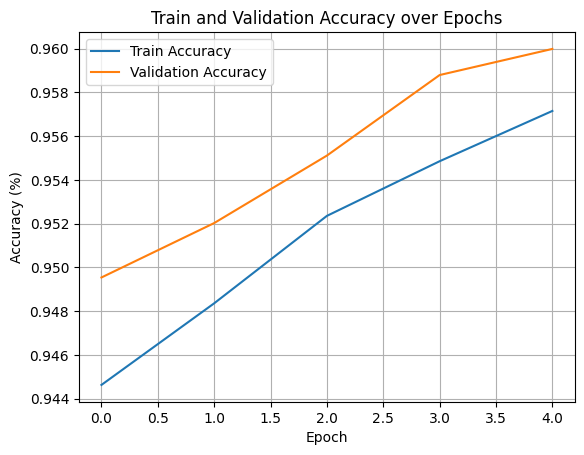

In [36]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that? **From the plot, the model accuracy is still improving after 5 epochs. This suggests that the model has not fully converged yet and additional epochs could improve performance further. However, if validation accuracy eventually stops improving or decreases while training accuracy keeps increasing, overfitting may occur.**

- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction. **The notebook currently computes training accuracy during parameter updates, which causes unstable measurements and artificially lower training accuracy. The validation accuracy is computed after training updates and in evaluation mode, making it appear higher. Replace the entire validation/training block with the corrected version below.**



#####**Edit: validation fix**

*prompt*: generate pytorch code to correctly compute train and validation accuracy per epoch using evaluation mode

In [37]:
'''
# Modifications made:
# - Corrected train accuracy computation
# - Added separate evaluation phase
# - Prevented training accuracy underestimation
# - Added loss tracking
num_epochs = 5

def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': [], 'train_loss': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}'))
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    train_accuracies = []
    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            train_accuracies.append(compute_accuracy(outputs, labels))
    train_accuracy = sum(train_accuracies) / len(train_accuracies)

    val_accuracies = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            val_accuracies.append(compute_accuracy(outputs, labels))
    val_accuracy = sum(val_accuracies) / len(val_accuracies)

    history['epoch'].append(epoch + 1)
    history['train_accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)
    history['train_loss'].append(running_loss / len(train_loader))

    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    '''

'\n# Modifications made:\n# - Corrected train accuracy computation\n# - Added separate evaluation phase\n# - Prevented training accuracy underestimation\n# - Added loss tracking\nnum_epochs = 5\n\ndef compute_accuracy(outputs, labels):\n    _, predicted = torch.max(outputs.data, 1)\n    correct = (predicted == labels).sum().item()\n    total = len(labels)\n    return correct / total\n\nhistory = {\'epoch\': [], \'train_accuracy\': [], \'val_accuracy\': [], \'train_loss\': []}\n\nfor epoch in range(num_epochs):\n    print(f\'epoch: {epoch+1}; time: {round(time.time())}\'))\n    model.train()\n    running_loss = 0\n    for images, labels in train_loader:\n        images = images.to(device)  #<<<<<<<<<< move data to device\n        labels = labels.to(device)  #<<<<<<<<<< move data to device\n        outputs = model(images)\n        loss = criterion(outputs, labels)\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n        running_loss += loss.item()\n\n   

The original notebook computed training accuracy during training mode while weights were still being updated. This caused noisier predictions and lower measured training accuracy. Meanwhile, validation accuracy was computed after training, with `model.eval()` and without parameter updates. The correction was to evaluate both train and validation accuracy after the epoch, use `model.eval()` and use `torch.no_grad()`. After correction, the curves become more consistent and realistic.